# Employee Attrition Machine Learning

This notebook supports two business goals: identify factors associated with employees leaving, and improve retention in high-risk departments and job roles. The model estimates an employee's probability of attrition so HR can prioritize supportive interventions.

Hypotheses explored include job role, promotion history, monthly income, overtime, satisfaction, work-life balance, travel, distance from home, tenure, stock options, and department.

In [7]:
from pathlib import Path
import sys

ROOT = Path.cwd() if (Path.cwd() / 'ml_model.py').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, roc_auc_score
from ml_model import load_data, feature_columns, train_model, save_model

data = load_data()
data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AgeBracket,Tenure,AnnualIncome,SatisfactionScore,AttritionBinary
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,1,6,4,0,5,36-45,Established (6-10),71916,2.00,1
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,3,10,7,1,7,46-55,Established (6-10),61560,3.00,0
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,3,0,0,0,0,36-45,New Hire (0-2),25080,3.00,1
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,...,3,8,7,3,0,26-35,Established (6-10),34908,3.25,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,...,3,2,2,2,2,26-35,New Hire (0-2),41616,2.50,0


In [8]:
print(f"Rows: {len(data):,}; columns: {data.shape[1]}")
print(data['Attrition'].value_counts(normalize=True).mul(100).round(2))
display(data.groupby('JobRole')['AttritionBinary'].agg(['count', 'mean']).sort_values('mean', ascending=False).style.format({'mean': '{:.1%}'}))
display(data.groupby('Department')['AttritionBinary'].agg(['count', 'mean']).style.format({'mean': '{:.1%}'}))

Rows: 1,470; columns: 37
Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


,count,mean
JobRole,,
Sales Representative,83,39.8%
Laboratory Technician,259,23.9%
Human Resources,52,23.1%
Sales Executive,326,17.5%
Research Scientist,292,16.1%
Manufacturing Director,145,6.9%
Healthcare Representative,131,6.9%
Manager,102,4.9%
Research Director,80,2.5%


,count,mean
Department,,
Human Resources,63,19.0%
Research & Development,961,13.8%
Sales,446,20.6%


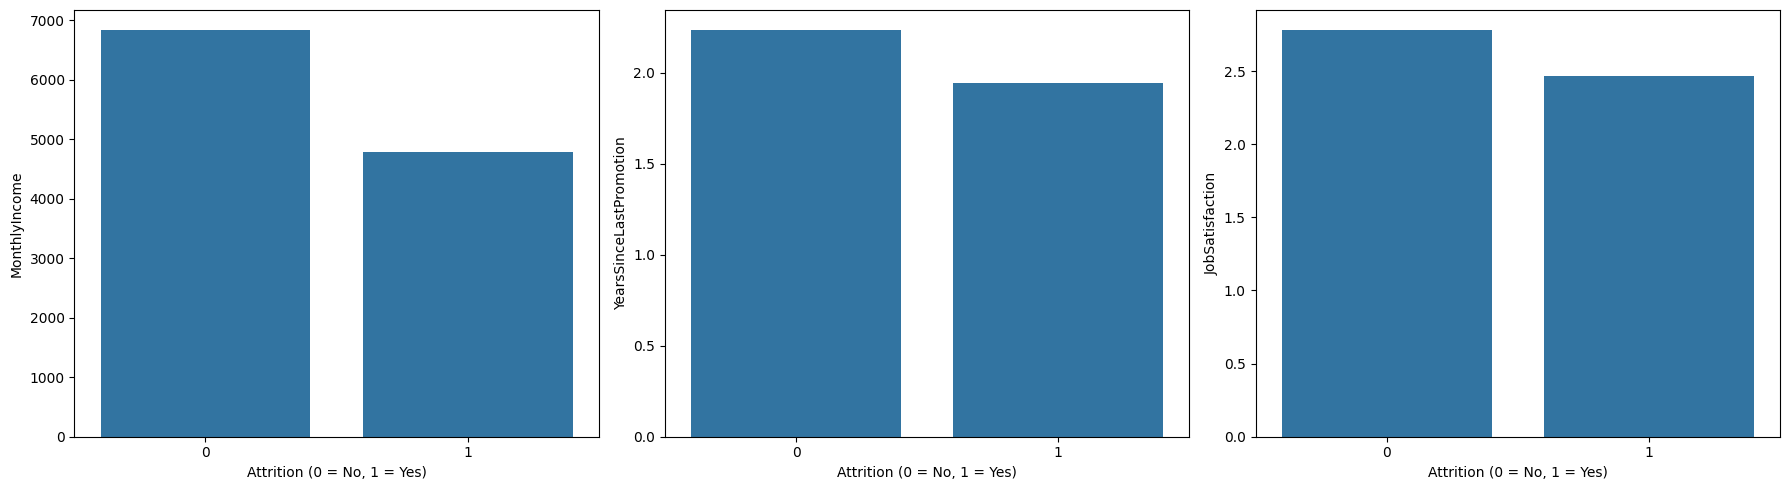

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(data=data, x='AttritionBinary', y='MonthlyIncome', ax=axes[0], errorbar=None)
sns.barplot(data=data, x='AttritionBinary', y='YearsSinceLastPromotion', ax=axes[1], errorbar=None)
sns.barplot(data=data, x='AttritionBinary', y='JobSatisfaction', ax=axes[2], errorbar=None)
for axis in axes:
    axis.set_xlabel('Attrition (0 = No, 1 = Yes)')
plt.tight_layout()

## Train and evaluate a risk model

The preprocessing is fitted only on the training split. Categorical variables are one-hot encoded, numeric variables are scaled, and class balancing addresses the minority attrition class. Employee number and the target/duplicate label are excluded to prevent leakage.

Accuracy: 0.772
ROC-AUC: 0.820
              precision    recall  f1-score   support

      Stayed       0.93      0.79      0.85       247
        Left       0.38      0.70      0.50        47

    accuracy                           0.77       294
   macro avg       0.66      0.74      0.67       294
weighted avg       0.84      0.77      0.80       294



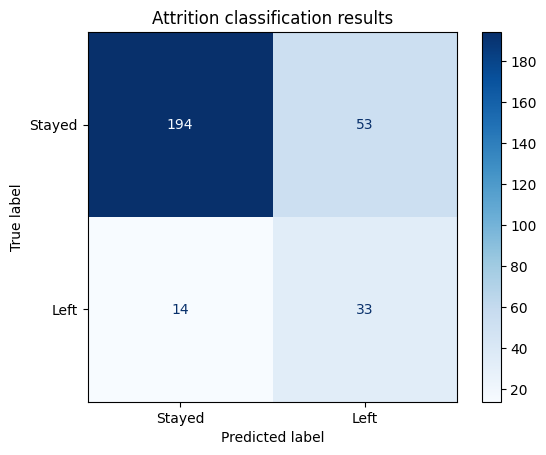

In [10]:
model, x_test, y_test, metrics = train_model(data)
print(f"Accuracy: {metrics['accuracy']:.3f}")
print(f"ROC-AUC: {metrics['roc_auc']:.3f}")
print(classification_report(metrics['y_test'], metrics['predictions'], target_names=['Stayed', 'Left']))
ConfusionMatrixDisplay.from_predictions(metrics['y_test'], metrics['predictions'], display_labels=['Stayed', 'Left'], cmap='Blues')
plt.title('Attrition classification results')
plt.show()
save_model(model)

In [11]:
feature_names = model.named_steps['preprocessor'].get_feature_names_out()
coefficients = pd.DataFrame({'Feature': feature_names, 'Coefficient': model.named_steps['classifier'].coef_[0]})
display(coefficients.assign(Absolute=lambda frame: frame['Coefficient'].abs()).sort_values('Absolute', ascending=False).head(20).drop(columns='Absolute'))

,Feature,Coefficient
44,categorical__JobRole_Research Director,-1.539541
41,categorical__JobRole_Laboratory Technician,1.136951
47,categorical__JobRole_Sales Representative,1.095730
25,categorical__BusinessTravel_Non-Travel,-0.942644
31,categorical__EducationField_Human Resources,0.911381
52,categorical__OverTime_Yes,0.851915
51,categorical__OverTime_No,-0.848914
26,categorical__BusinessTravel_Travel_Frequently,0.847806
35,categorical__EducationField_Other,-0.733756
55,categorical__AgeBracket_36-45,-0.717049


In [12]:
scored = data.copy()
scored['Attrition probability'] = model.predict_proba(scored[feature_columns(data)])[:, 1]
scored['Risk band'] = pd.cut(scored['Attrition probability'], bins=[-0.01, 0.30, 0.60, 1.0], labels=['Low', 'Medium', 'High'])
display(scored.sort_values('Attrition probability', ascending=False)[['EmployeeNumber', 'Department', 'JobRole', 'Attrition probability', 'Risk band']].head(10))

,EmployeeNumber,Department,JobRole,Attrition probability,Risk band
1060,1494,Research & Development,Laboratory Technician,0.994790,High
911,1273,Sales,Sales Representative,0.991488,High
463,622,Research & Development,Laboratory Technician,0.991108,High
357,478,Sales,Sales Representative,0.990609,High
1396,1968,Sales,Sales Executive,0.990184,High
457,614,Sales,Sales Representative,0.989573,High
688,959,Sales,Sales Representative,0.984171,High
798,1108,Research & Development,Research Scientist,0.982052,High
1057,1487,Sales,Sales Executive,0.981302,High
1153,1624,Sales,Sales Representative,0.977311,High
